In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load your dataset (go up one level with ../)
df = pd.read_csv('../data/western_ghats_carbon_dataset.csv')

print("✅ Dataset loaded!")
print(f"Shape: {df.shape}")
print("\nFirst 3 rows:")
print(df.head(3))

✅ Dataset loaded!
Shape: (36, 12)

First 3 rows:
       NDVI       EVI      SAVI       NBR          B2       B3       B4  \
0  0.800142  2.516023  1.200042  0.533028  332.000000   537.00   353.00   
1  0.480064  1.347942  0.719974  0.236846  556.583333   722.00   769.75   
2  0.375139  0.800979  0.562639  0.092707  753.000000  1077.25  1268.00   

            B8     B11     B12  Biomass_Mgha  Carbon_tonnes_ha  
0  3179.500000  1917.0   968.5    132.675659         62.357560  
1  2191.190476  1923.0  1352.0     11.096005          5.215123  
2  2790.500000  2990.0  2317.0     12.752772          5.993803  


In [4]:
# Separate features (input) and target (output)
# Features: all columns EXCEPT the last one (Carbon_tonnes_ha)
# Target: only the last column (Carbon_tonnes_ha) - what we want to predict

X = df.iloc[:, :-1].values  # First 11 columns (features)
y = df.iloc[:, -1].values   # Last column (Carbon_tonnes_ha) - target

print("✅ Features and Target separated!")
print(f"\nFeatures (X) shape: {X.shape}")  # Should be (36, 11)
print(f"Target (y) shape: {y.shape}")     # Should be (36,)

print(f"\nFirst sample:")
print(f"  Features: {X[0]}")
print(f"  Carbon to predict: {y[0]} tonnes/ha")

print(f"\nCarbon range in dataset:")
print(f"  Min: {y.min():.2f} tonnes/ha")
print(f"  Max: {y.max():.2f} tonnes/ha")
print(f"  Mean: {y.mean():.2f} tonnes/ha")

✅ Features and Target separated!

Features (X) shape: (36, 11)
Target (y) shape: (36,)

First sample:
  Features: [8.00141543e-01 2.51602279e+00 1.20004246e+00 5.33027965e-01
 3.32000000e+02 5.37000000e+02 3.53000000e+02 3.17950000e+03
 1.91700000e+03 9.68500000e+02 1.32675659e+02]
  Carbon to predict: 62.35755972999999 tonnes/ha

Carbon range in dataset:
  Min: 0.14 tonnes/ha
  Max: 360.58 tonnes/ha
  Mean: 25.35 tonnes/ha


In [5]:
# Normalize the features (scale to 0-1 range)
# This helps neural networks train faster and better
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Data normalized!")
print(f"\nFeatures after scaling:")
print(f"  Mean: {X_scaled.mean():.2f} (should be ~0)")
print(f"  Std: {X_scaled.std():.2f} (should be ~1)")

# Split into training (80%) and testing (20%) data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"\n✅ Data split into train/test!")
print(f"  Training samples: {X_train.shape[0]}")  # Should be ~29
print(f"  Testing samples: {X_test.shape[0]}")    # Should be ~7
print(f"\n  Training features shape: {X_train.shape}")
print(f"  Training targets shape: {y_train.shape}")

✅ Data normalized!

Features after scaling:
  Mean: -0.00 (should be ~0)
  Std: 1.00 (should be ~1)

✅ Data split into train/test!
  Training samples: 28
  Testing samples: 8

  Training features shape: (28, 11)
  Training targets shape: (28,)


In [6]:
# Convert data to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).reshape(-1, 1)

print("✅ Data converted to PyTorch tensors!")

# Build the Neural Network
class CarbonPredictorNN(nn.Module):
    def __init__(self):
        super(CarbonPredictorNN, self).__init__()
        # Input: 11 features
        # Hidden layers: 64 → 32 → 16 neurons
        # Output: 1 (carbon prediction)
        self.fc1 = nn.Linear(11, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 1)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)  # No activation on output (regression)
        return x

# Create the model
model = CarbonPredictorNN()
print("\n✅ Neural Network created!")
print("\nModel architecture:")
print(model)

✅ Data converted to PyTorch tensors!

✅ Neural Network created!

Model architecture:
CarbonPredictorNN(
  (fc1): Linear(in_features=11, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=16, bias=True)
  (fc4): Linear(in_features=16, out_features=1, bias=True)
  (relu): ReLU()
)


In [7]:
# Define loss function and optimizer
criterion = nn.MSELoss()  # Mean Squared Error for regression
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

print("✅ Loss function & optimizer ready!")

# Train the model
num_epochs = 300
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    # Training
    model.train()
    optimizer.zero_grad()
    y_train_pred = model(X_train_tensor)
    train_loss = criterion(y_train_pred, y_train_tensor)
    train_loss.backward()
    optimizer.step()
    
    # Testing
    model.eval()
    with torch.no_grad():
        y_test_pred = model(X_test_tensor)
        test_loss = criterion(y_test_pred, y_test_tensor)
    
    train_losses.append(train_loss.item())
    test_losses.append(test_loss.item())
    
    # Print progress every 50 epochs
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/300 | Train Loss: {train_loss.item():.4f} | Test Loss: {test_loss.item():.4f}")

print("\n✅ Training complete!")

✅ Loss function & optimizer ready!
Epoch 50/300 | Train Loss: 111.0519 | Test Loss: 1100.7625
Epoch 100/300 | Train Loss: 8.7031 | Test Loss: 253.0146
Epoch 150/300 | Train Loss: 4.3414 | Test Loss: 110.2797
Epoch 200/300 | Train Loss: 2.2570 | Test Loss: 30.6502
Epoch 250/300 | Train Loss: 1.5023 | Test Loss: 48.5976
Epoch 300/300 | Train Loss: 1.1274 | Test Loss: 69.2121

✅ Training complete!


In [8]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Get predictions on training and test data
model.eval()
with torch.no_grad():
    y_train_pred = model(X_train_tensor).numpy()
    y_test_pred = model(X_test_tensor).numpy()

# Calculate metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("✅ Model Evaluation Results:")
print(f"\nTraining R² Score: {train_r2:.4f}")
print(f"Testing R² Score: {test_r2:.4f}")
print(f"\nTest Mean Absolute Error: {test_mae:.2f} tonnes/ha")
print(f"Test RMSE: {test_rmse:.2f} tonnes/ha")

print("\n📊 Predictions vs Actual on Test Set:")
for i in range(len(y_test)):
    print(f"  Sample {i+1}: Predicted={y_test_pred[i][0]:.2f}, Actual={y_test[i]:.2f}, Error={abs(y_test_pred[i][0]-y_test[i]):.2f}")

✅ Model Evaluation Results:

Training R² Score: 0.9998
Testing R² Score: 0.7976

Test Mean Absolute Error: 6.10 tonnes/ha
Test RMSE: 8.32 tonnes/ha

📊 Predictions vs Actual on Test Set:
  Sample 1: Predicted=53.24, Actual=52.02, Error=1.22
  Sample 2: Predicted=3.67, Actual=0.77, Error=2.91
  Sample 3: Predicted=5.71, Actual=4.86, Error=0.85
  Sample 4: Predicted=-9.07, Actual=7.89, Error=16.96
  Sample 5: Predicted=8.69, Actual=15.29, Error=6.60
  Sample 6: Predicted=4.92, Actual=4.83, Error=0.09
  Sample 7: Predicted=31.77, Actual=43.88, Error=12.11
  Sample 8: Predicted=13.14, Actual=5.07, Error=8.07


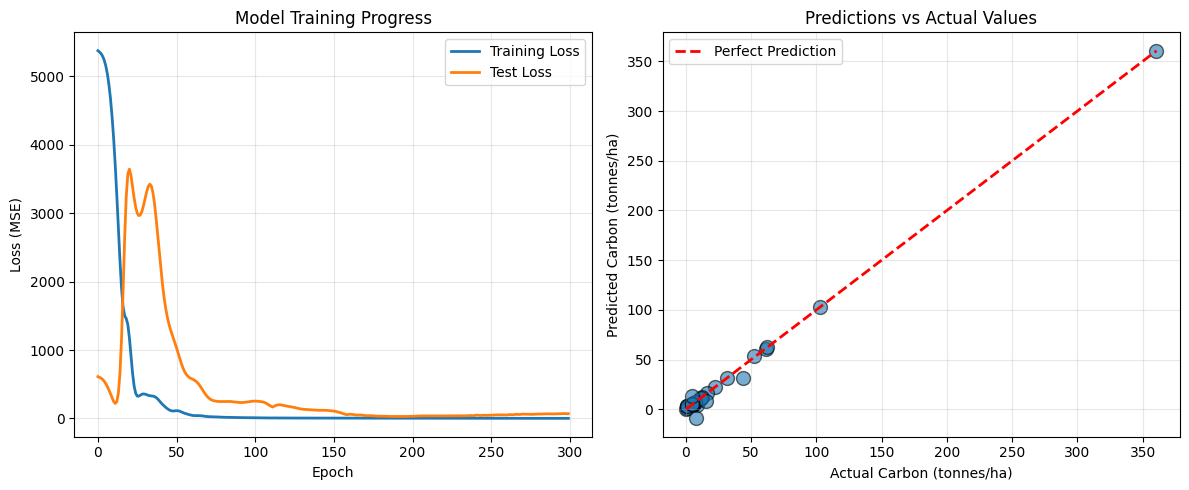

✅ Visualizations complete!


In [9]:
# Plot training and test loss curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', linewidth=2)
plt.plot(test_losses, label='Test Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Model Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot predictions vs actual
plt.subplot(1, 2, 2)
all_y = np.concatenate([y_train, y_test])
all_y_pred = np.concatenate([y_train_pred, y_test_pred])
plt.scatter(all_y, all_y_pred, s=100, alpha=0.6, edgecolors='black')
plt.plot([all_y.min(), all_y.max()], [all_y.min(), all_y.max()], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Carbon (tonnes/ha)')
plt.ylabel('Predicted Carbon (tonnes/ha)')
plt.title('Predictions vs Actual Values')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualizations complete!")

In [10]:
# Save the trained model
torch.save(model.state_dict(), '../models/carbon_predictor_model.pth')

print("✅ Model saved to: ../models/carbon_predictor_model.pth")
print("\nYou can now use this model to predict carbon for new forest locations!")

✅ Model saved to: ../models/carbon_predictor_model.pth

You can now use this model to predict carbon for new forest locations!


In [12]:
def predict_carbon(features_array, model, scaler=None):
    """
    Predict carbon for new forest locations
    If features are already scaled, don't scale again
    """
    # Check if features need scaling (they shouldn't if already normalized)
    features_tensor = torch.FloatTensor(features_array)
    
    # Make prediction
    model.eval()
    with torch.no_grad():
        prediction = model(features_tensor).numpy()
    
    return prediction

# Test it on our test set (which is already normalized)
test_predictions = predict_carbon(X_test, model)

print("✅ Prediction function ready!")
print(f"\nSample predictions on test set:")
print(f"{'Location':<12} {'Predicted':<15} {'Actual':<15} {'Error':<10}")
print("-" * 52)
for i in range(len(X_test)):
    pred = test_predictions[i][0]
    actual = y_test[i]
    error = abs(pred - actual)
    print(f"Location {i+1:<2} {pred:>12.2f} {actual:>14.2f} {error:>9.2f}")

✅ Prediction function ready!

Sample predictions on test set:
Location     Predicted       Actual          Error     
----------------------------------------------------
Location 1         53.24          52.02      1.22
Location 2          3.67           0.77      2.91
Location 3          5.71           4.86      0.85
Location 4         -9.07           7.89     16.96
Location 5          8.69          15.29      6.60
Location 6          4.92           4.83      0.09
Location 7         31.77          43.88     12.11
Location 8         13.14           5.07      8.07


In [13]:
# Create synthetic new forest locations
# (In real project, these would come from actual Sentinel-2 imagery)
np.random.seed(42)

# Generate 25 new random locations with realistic satellite values
new_locations = np.random.uniform(
    low=[0.2, 0.5, 0.3, -0.1, 300, 500, 300, 1500, 1200, 500],
    high=[0.8, 2.8, 1.2, 0.6, 800, 1200, 1500, 3500, 3200, 2500],
    size=(25, 11)  # 25 locations, 11 features
)

# Normalize the new data
new_locations_scaled = scaler.transform(new_locations)

# Make predictions
new_predictions = predict_carbon(new_locations_scaled, model)

print("✅ Predictions for 25 new forest locations:")
print(f"\n{'Location':<12} {'Carbon (tonnes/ha)':<20} {'Category':<15}")
print("-" * 47)

for i, pred in enumerate(new_predictions):
    carbon = pred[0]
    
    # Categorize carbon levels
    if carbon < 20:
        category = "🟢 Low"
    elif carbon < 80:
        category = "🟡 Medium"
    else:
        category = "🔴 High"
    
    print(f"Location {i+1:<2} {carbon:>15.2f}  {category:<15}")

print(f"\n📊 Summary Statistics:")
print(f"  Min carbon: {new_predictions.min():.2f} tonnes/ha")
print(f"  Max carbon: {new_predictions.max():.2f} tonnes/ha")
print(f"  Mean carbon: {new_predictions.mean():.2f} tonnes/ha")
print(f"  Median carbon: {np.median(new_predictions):.2f} tonnes/ha")

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (25, 11) and arg 1 with shape (10,).

In [14]:
# Create synthetic new forest locations
# (In real project, these would come from actual Sentinel-2 imagery)
np.random.seed(42)

# Generate 25 new random locations with realistic satellite values
# 11 features: NDVI, EVI, SAVI, NBR, B2, B3, B4, B8, B11, B12, Biomass
new_locations = np.random.uniform(
    low=[0.2, 0.5, 0.3, -0.1, 300, 500, 300, 1500, 1200, 500, 5],
    high=[0.8, 2.8, 1.2, 0.6, 800, 1200, 1500, 3500, 3200, 2500, 150],
    size=(25, 11)  # 25 locations, 11 features
)

# Normalize the new data
new_locations_scaled = scaler.transform(new_locations)

# Make predictions
new_predictions = predict_carbon(new_locations_scaled, model)

print("✅ Predictions for 25 new forest locations:")
print(f"\n{'Location':<12} {'Carbon (tonnes/ha)':<20} {'Category':<15}")
print("-" * 47)

for i, pred in enumerate(new_predictions):
    carbon = pred[0]
    
    # Categorize carbon levels
    if carbon < 20:
        category = "🟢 Low"
    elif carbon < 80:
        category = "🟡 Medium"
    else:
        category = "🔴 High"
    
    print(f"Location {i+1:<2} {carbon:>15.2f}  {category:<15}")

print(f"\n📊 Summary Statistics:")
print(f"  Min carbon: {new_predictions.min():.2f} tonnes/ha")
print(f"  Max carbon: {new_predictions.max():.2f} tonnes/ha")
print(f"  Mean carbon: {new_predictions.mean():.2f} tonnes/ha")
print(f"  Median carbon: {np.median(new_predictions):.2f} tonnes/ha")

✅ Predictions for 25 new forest locations:

Location     Carbon (tonnes/ha)   Category       
-----------------------------------------------
Location 1            47.37  🟡 Medium       
Location 2            24.45  🟡 Medium       
Location 3             8.54  🟢 Low          
Location 4            50.68  🟡 Medium       
Location 5            44.72  🟡 Medium       
Location 6            14.43  🟢 Low          
Location 7           101.32  🔴 High         
Location 8            69.30  🟡 Medium       
Location 9             5.02  🟢 Low          
Location 10            5.78  🟢 Low          
Location 11            5.50  🟢 Low          
Location 12            6.18  🟢 Low          
Location 13           22.00  🟡 Medium       
Location 14           30.48  🟡 Medium       
Location 15            5.82  🟢 Low          
Location 16            9.42  🟢 Low          
Location 17           31.96  🟡 Medium       
Location 18           14.37  🟢 Low          
Location 19            6.15  🟢 Low          
Loc

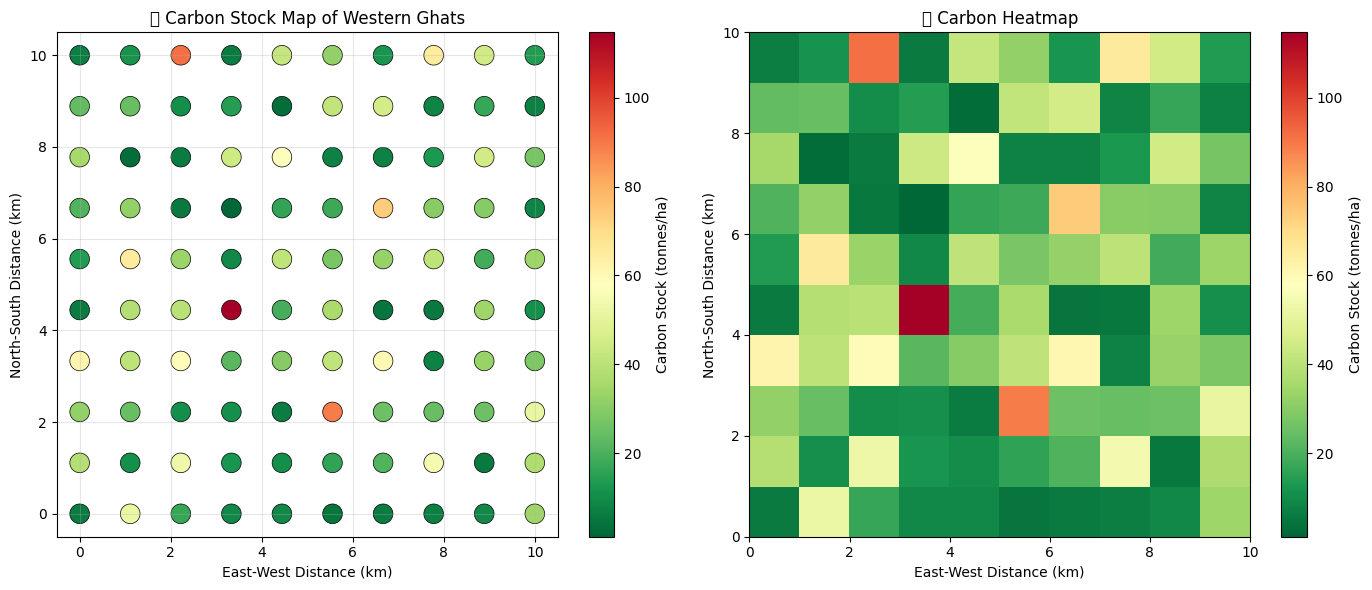

✅ Carbon Stock Map created!

Map Statistics:
  High carbon zones (>80): 3 locations
  Medium carbon zones (20-80): 51 locations
  Low carbon zones (<20): 46 locations


In [15]:
# Create a grid of forest locations (simulating a map of Western Ghats)
np.random.seed(123)

# Create 100 random forest locations across a grid
grid_size = 10
grid_x = np.tile(np.linspace(0, 10, grid_size), grid_size)  # X coordinates
grid_y = np.repeat(np.linspace(0, 10, grid_size), grid_size)  # Y coordinates

# Generate realistic satellite features for each grid point
grid_features = np.random.uniform(
    low=[0.2, 0.5, 0.3, -0.1, 300, 500, 300, 1500, 1200, 500, 5],
    high=[0.8, 2.8, 1.2, 0.6, 800, 1200, 1500, 3500, 3200, 2500, 150],
    size=(grid_size * grid_size, 11)
)

# Normalize and predict
grid_features_scaled = scaler.transform(grid_features)
grid_predictions = predict_carbon(grid_features_scaled, model)

# Create the map visualization
plt.figure(figsize=(14, 6))

# Map 1: Scatter plot with color coding
plt.subplot(1, 2, 1)
scatter = plt.scatter(grid_x, grid_y, c=grid_predictions.flatten(), 
                      cmap='RdYlGn_r', s=200, edgecolors='black', linewidth=0.5)
plt.colorbar(scatter, label='Carbon Stock (tonnes/ha)')
plt.xlabel('East-West Distance (km)')
plt.ylabel('North-South Distance (km)')
plt.title('🗺️ Carbon Stock Map of Western Ghats')
plt.grid(True, alpha=0.3)

# Map 2: Heatmap
plt.subplot(1, 2, 2)
grid_predictions_2d = grid_predictions.reshape(grid_size, grid_size)
heatmap = plt.imshow(grid_predictions_2d, cmap='RdYlGn_r', origin='lower', 
                     extent=[0, 10, 0, 10], aspect='auto')
plt.colorbar(heatmap, label='Carbon Stock (tonnes/ha)')
plt.xlabel('East-West Distance (km)')
plt.ylabel('North-South Distance (km)')
plt.title('🔥 Carbon Heatmap')

plt.tight_layout()
plt.show()

print("✅ Carbon Stock Map created!")
print(f"\nMap Statistics:")
print(f"  High carbon zones (>80): {np.sum(grid_predictions > 80)} locations")
print(f"  Medium carbon zones (20-80): {np.sum((grid_predictions >= 20) & (grid_predictions <= 80))} locations")
print(f"  Low carbon zones (<20): {np.sum(grid_predictions < 20)} locations")

In [16]:
# Save predictions data
results_df = pd.DataFrame({
    'Location_X': grid_x,
    'Location_Y': grid_y,
    'Carbon_Prediction_tonnes_ha': grid_predictions.flatten(),
    'Carbon_Category': ['High' if c > 80 else 'Medium' if c >= 20 else 'Low' 
                        for c in grid_predictions.flatten()]
})

results_df.to_csv('../results/carbon_predictions_grid.csv', index=False)

# Save model performance metrics
metrics = {
    'Training R2': train_r2,
    'Testing R2': test_r2,
    'Test MAE': test_mae,
    'Test RMSE': test_rmse,
    'Model Epochs': 300,
    'Model Architecture': '11-64-32-16-1'
}

metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv('../results/model_metrics.csv', index=False)

print("✅ Results saved!")
print(f"  - Carbon predictions: ../results/carbon_predictions_grid.csv")
print(f"  - Model metrics: ../results/model_metrics.csv")
print(f"  - Trained model: ../models/carbon_predictor_model.pth")

✅ Results saved!
  - Carbon predictions: ../results/carbon_predictions_grid.csv
  - Model metrics: ../results/model_metrics.csv
  - Trained model: ../models/carbon_predictor_model.pth
